# v2 — Step 04: Dimensionality Reduction, Batch Correction & Clustering

## Purpose
Reduce the 3,000-gene HVG space to interpretable embeddings (PCA → UMAP) and identify
cell clusters via the Leiden algorithm. Patient-level batch effects are removed using Harmony
before building the neighbourhood graph.

## Pipeline
1. **PCA** — linear reduction to 50 PCs; elbow plot guides how many to retain
2. **Harmony** — batch correction across patients A, B, C in PCA space
3. **Neighbour graph** — k-NN on the Harmony-corrected PCA embedding
4. **UMAP** — non-linear 2D visualisation for exploration
5. **Leiden clustering** — community detection at four resolutions (0.5, 0.8, 1.0, 1.2)

## Why Harmony?
This dataset comes from **3 patients (A, B, C)**, each contributing one healthy sample,
one UC non-inflamed sample, and one UC inflamed sample. Patient identity introduces
technical and genetic variation that is orthogonal to the biology of interest (condition).
Without correction, UMAPs can cluster by patient rather than by cell type, making
biological interpretation impossible.

Harmony operates in PCA space and iteratively adjusts PC coordinates to remove the
patient signal while preserving transcriptional differences between cell types.
The correction is verified by comparing PCA scatter plots before and after.

## Input
- `data/processed/v2/GSE116222_v2_preprocessed.h5ad`

## Output
- `data/processed/v2/GSE116222_v2_clustered.h5ad`

In [3]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.set_figure_params(dpi=150, facecolor='white', frameon=False)

CONDITION_ORDER   = ['Healthy', 'UC_noninflamed', 'UC_inflamed']
CONDITION_PALETTE = {'Healthy': '#4CAF50', 'UC_noninflamed': '#FF9800', 'UC_inflamed': '#F44336'}
PATIENT_PALETTE   = {'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#2ca02c'}
RANDOM_STATE      = 42

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/opt/homebrew/Caskroom/miniconda/base/

In [4]:
os.chdir("/Users/Vicky/vicky/UC_Single_Cell_analysis")
print("cwd:", os.getcwd())
adata = sc.read_h5ad('data/processed/v2/GSE116222_v2_preprocessed.h5ad')
print(f"Loaded: {adata.n_obs:,} cells × {adata.n_vars:,} genes")
print(f"obs metadata: {list(adata.obs.columns)}")

cwd: /Users/Vicky/vicky/UC_Single_Cell_analysis
Loaded: 7,791 cells × 3,000 genes
obs metadata: ['sample', 'condition', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'log1p_total_counts_ribo']


## Step 1 — PCA

PCA reduces 3,000 HVGs to 50 principal components. We compute 50 to give the elbow
plot enough range; the actual number used for neighbourhood building will be determined
by where explained variance plateaus (typically 20–35 for datasets of this complexity).

In [5]:
sc.pp.pca(adata, n_comps=50, random_state=RANDOM_STATE)
print(f"PCA complete. Representation stored in adata.obsm['X_pca']")
print(f"Shape: {adata.obsm['X_pca'].shape}")

PCA complete. Representation stored in adata.obsm['X_pca']
Shape: (7791, 50)


/var/folders/mr/f3825hy10rjbrjd_85fs57bc0000gp/T/ipykernel_8435/2897280216.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


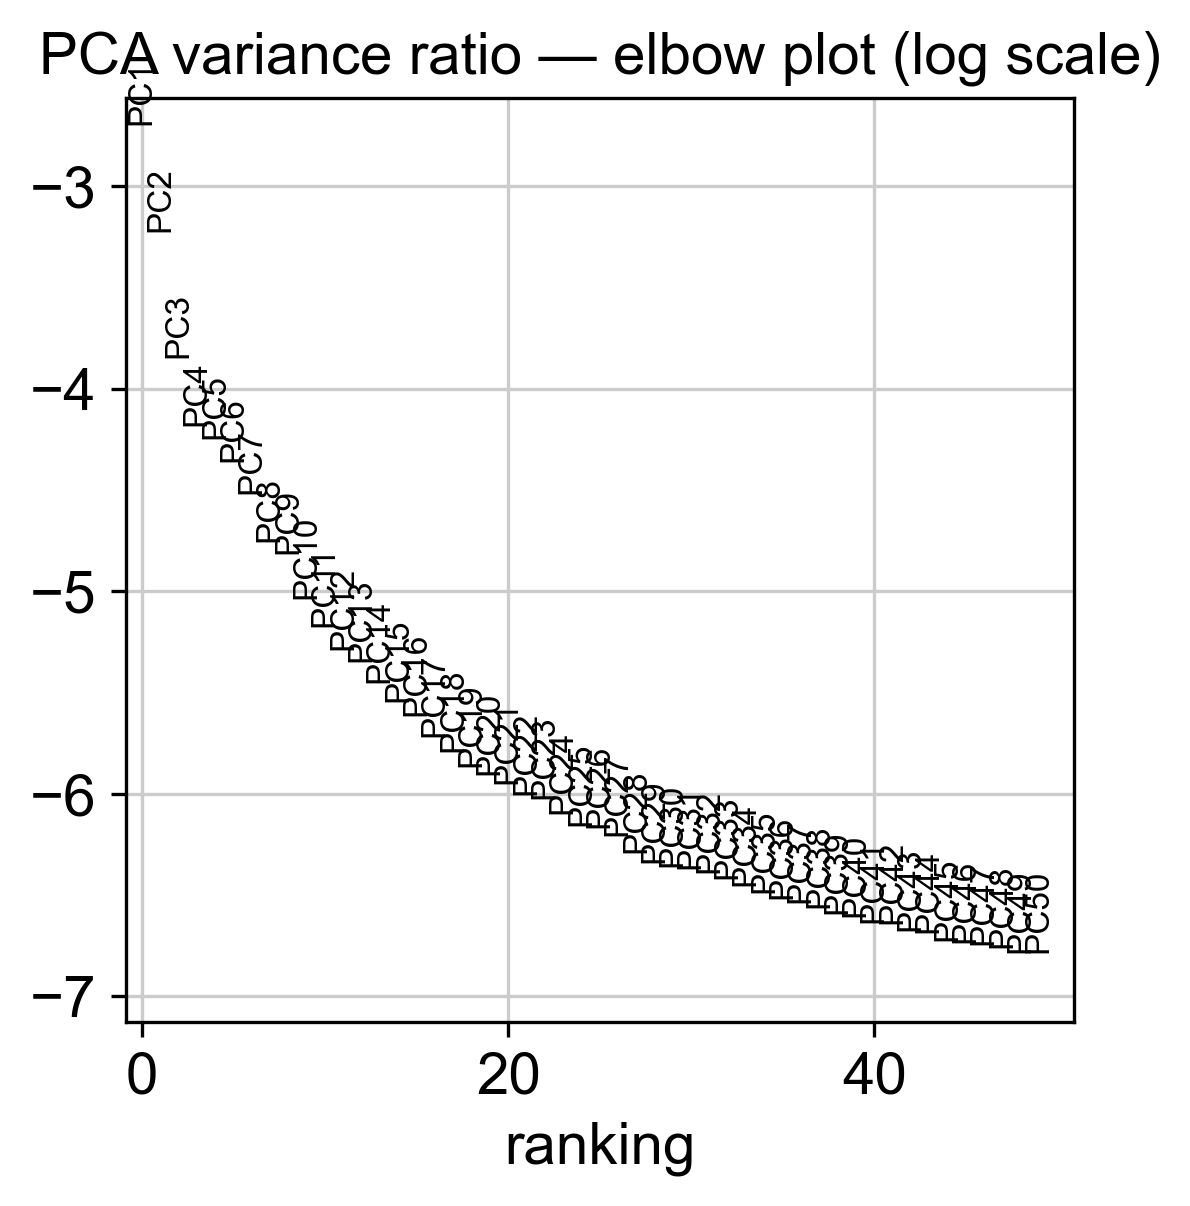

In [6]:
# Elbow plot: choose the number of PCs to retain
# The elbow is where the variance explained per PC starts to flatten,
# indicating that additional PCs capture mostly noise
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True, show=False)
plt.title('PCA variance ratio — elbow plot (log scale)')
plt.tight_layout()
plt.savefig('figures/v2/04_pca_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


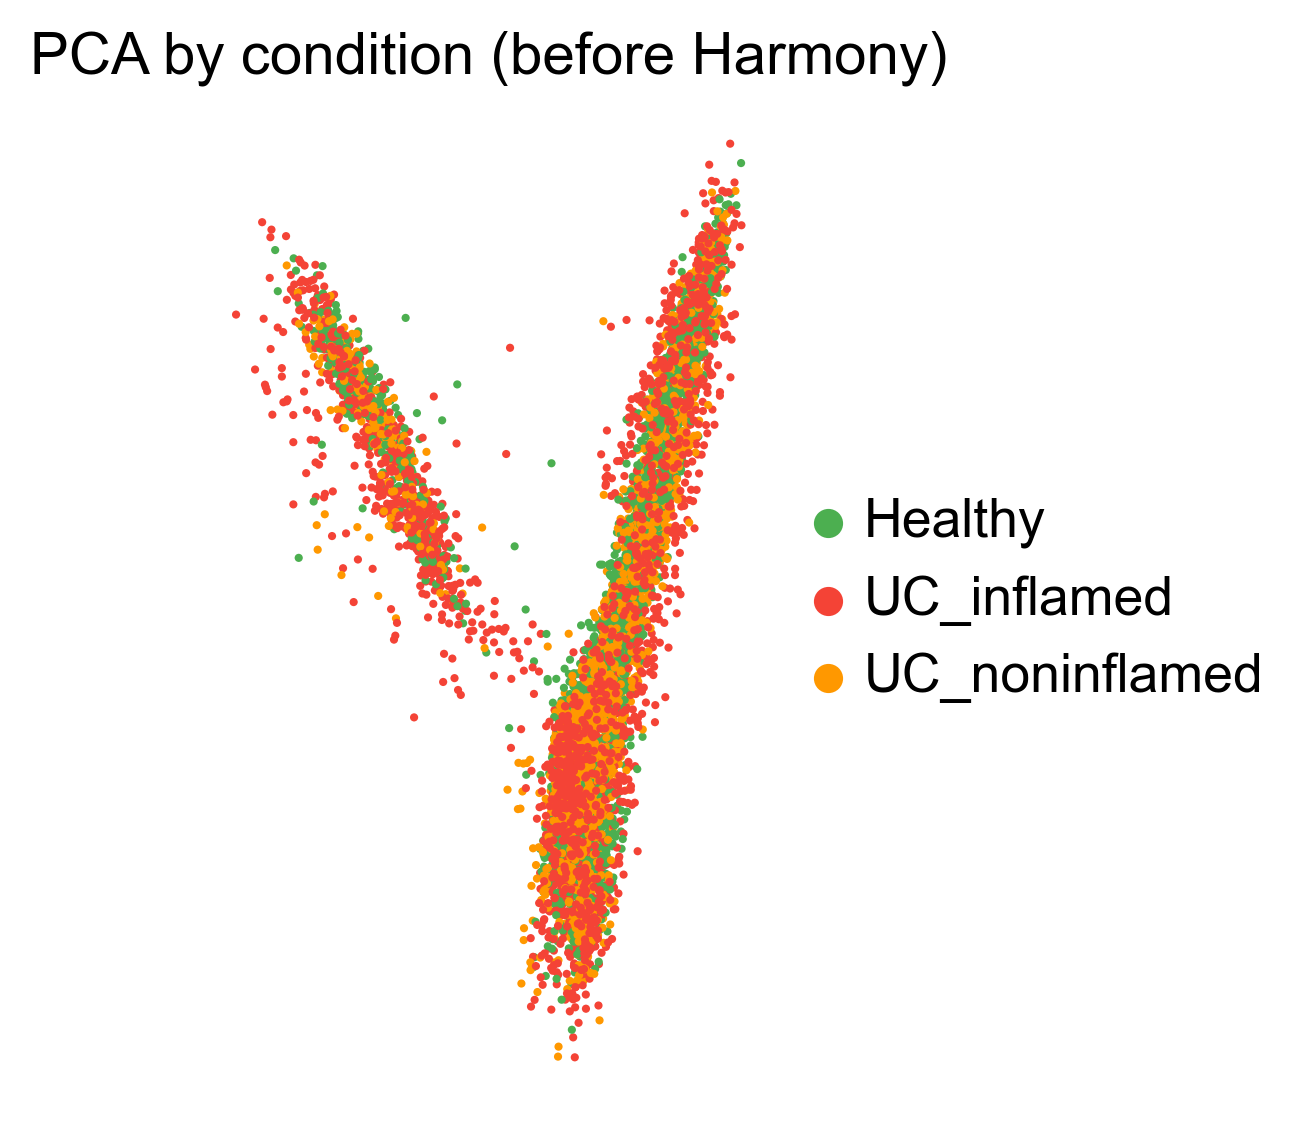

In [7]:
# PCA scatter coloured by condition — before Harmony
# Good batch correction should not change the condition signal
sc.pl.pca(
    adata, color='condition',
    palette=CONDITION_PALETTE,
    title='PCA by condition (before Harmony)',
    show=False
)
plt.tight_layout()
plt.savefig('figures/v2/04_pca_by_condition_pre_harmony.png', dpi=150, bbox_inches='tight')
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


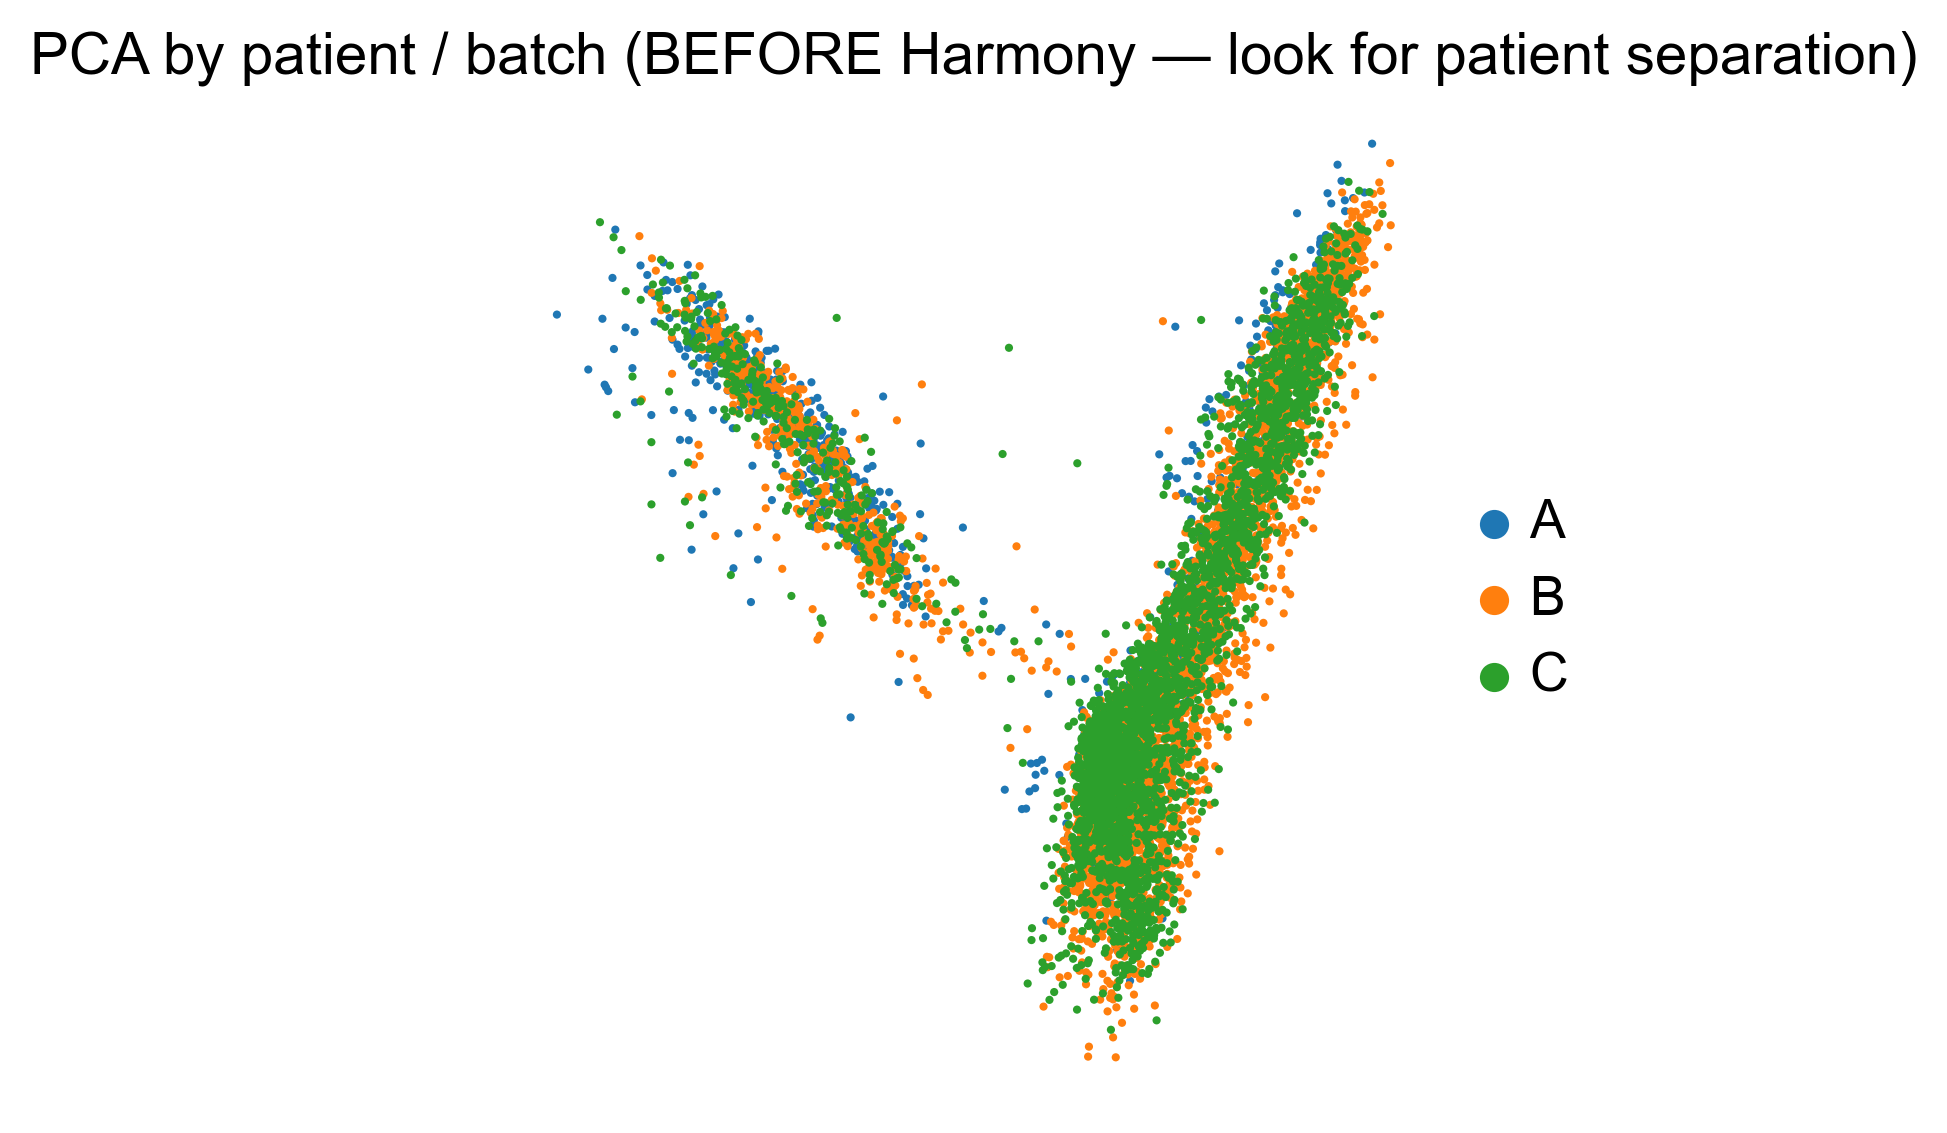

In [8]:
# PCA scatter coloured by patient — before Harmony
# If patient clusters are visible here, batch correction is needed
sc.pl.pca(
    adata, color='batch',
    palette=PATIENT_PALETTE,
    title='PCA by patient / batch (BEFORE Harmony — look for patient separation)',
    show=False
)
plt.tight_layout()
plt.savefig('figures/v2/04_pca_by_patient_pre_harmony.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2 — Harmony batch correction

Harmony (`sc.external.pp.harmony_integrate`) adjusts the PCA coordinates to minimise
the clustering of cells by patient (the `batch` column) while preserving the variance
driven by cell type.

The result is stored in `adata.obsm['X_pca_harmony']`. All downstream steps
(neighbour graph, UMAP, Leiden) use this corrected embedding.

**Key parameter**: `key='batch'` specifies that patient identity is the batch variable.
Here `batch` encodes patients A, B, C.

In [19]:

# Run Harmony batch correction
import harmonypy

print("Running Harmony batch correction...")
harmony_out = harmonypy.run_harmony(
    adata.obsm['X_pca'],      # Input: (7791, 50)
    adata.obs,
    'batch',                  # Batch variable name
    verbose=False
)

# harmonypy returns Z_corr already in correct shape (7791, 50)
# Do NOT transpose
adata.obsm['X_pca_harmony'] = harmony_out.Z_corr
print(f"Harmony complete. Corrected embedding: adata.obsm['X_pca_harmony']")
print(f"Shape: {adata.obsm['X_pca_harmony'].shape}")


2026-03-12 08:52:28,034 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-12 08:52:28,183 - harmonypy - INFO - KMeans initialization complete.


Running Harmony batch correction...
Harmony complete. Corrected embedding: adata.obsm['X_pca_harmony']
Shape: (7791, 50)


In [20]:
# Visualise Harmony result — compute a temporary UMAP on the harmony embedding
# to compare patient mixing before vs after
# (We will compute the final UMAP after building neighbours)
sc.pp.neighbors(
    adata,
    use_rep='X_pca_harmony',
    n_neighbors=15,
    n_pcs=30,
    random_state=RANDOM_STATE
)
sc.tl.umap(adata, min_dist=0.5, random_state=RANDOM_STATE)
print("UMAP computed.")

UMAP computed.


## Step 3 — Verify Harmony correction

After correction, patients A, B, C should be intermixed on UMAP — the same cell types
from different patients should overlap. If patient clusters persist, the correction was
insufficient and batch covariate selection should be revisited.

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


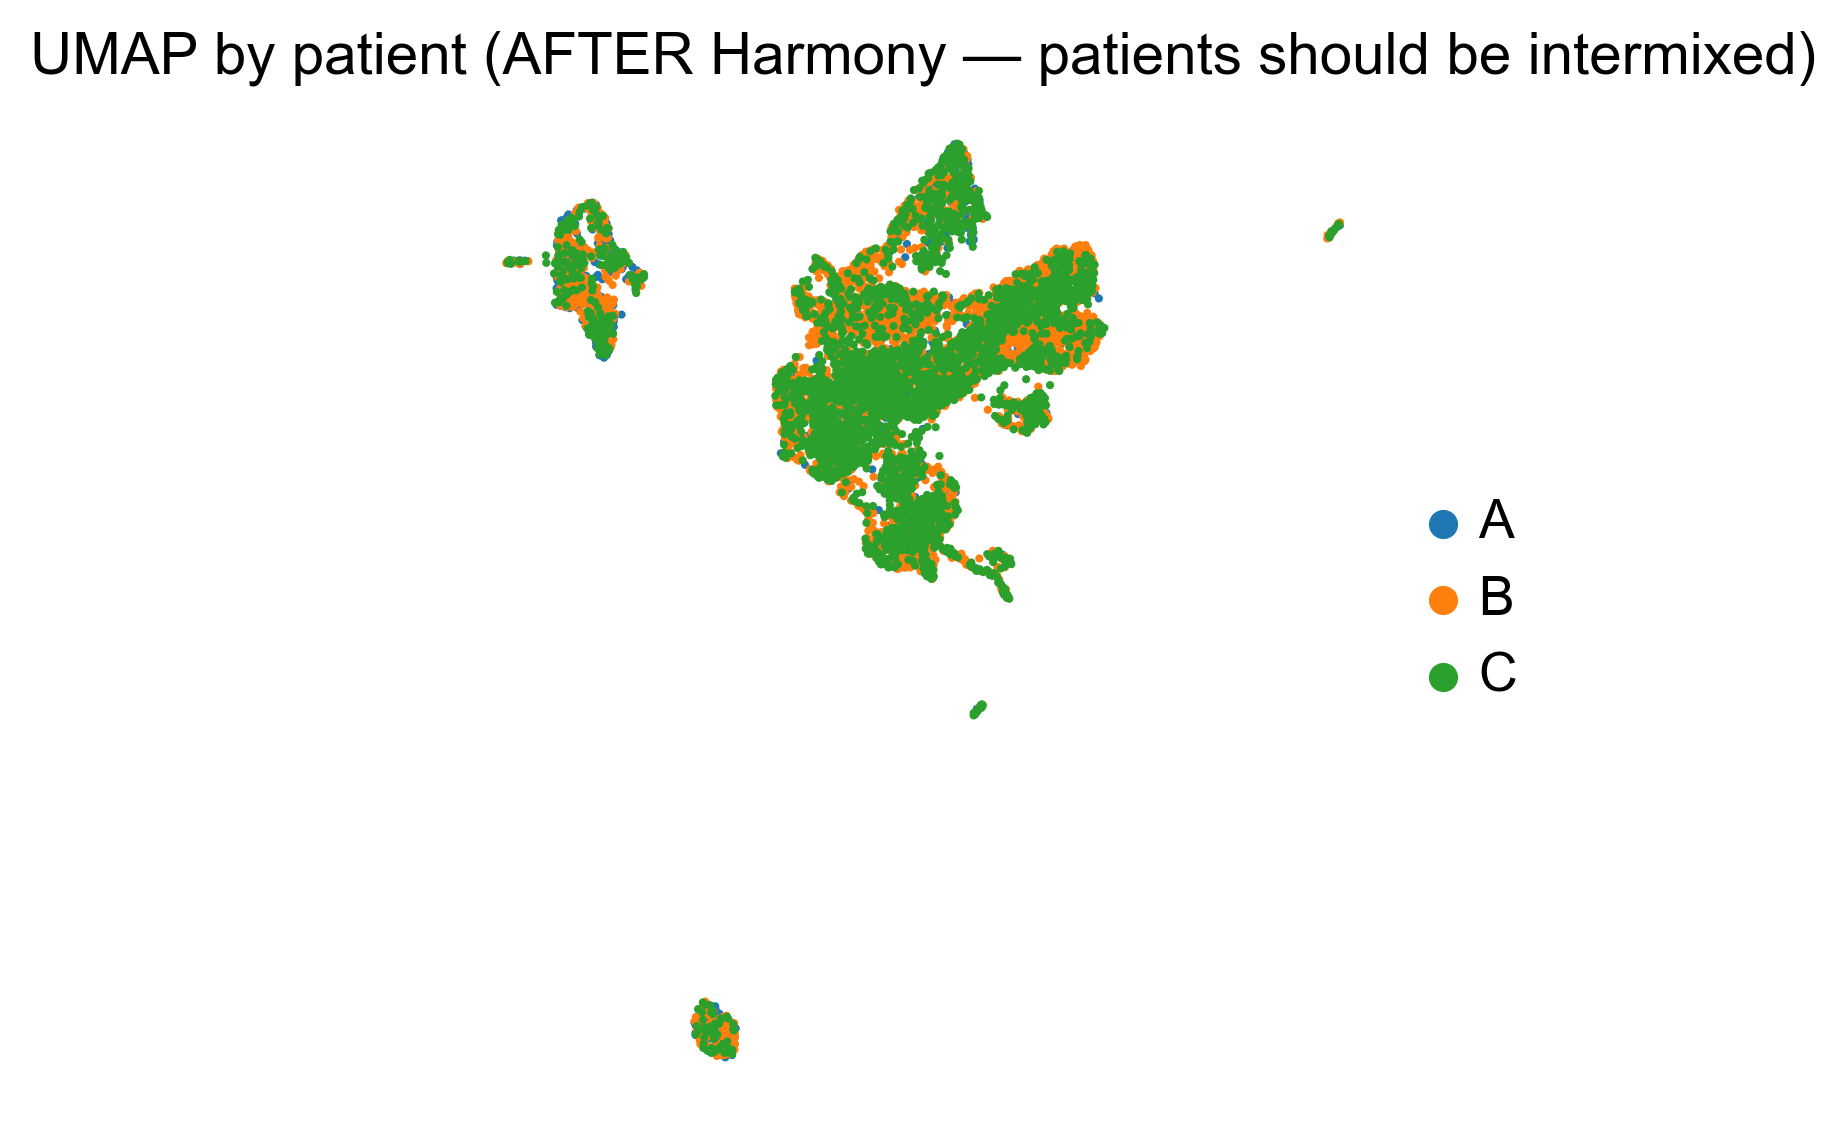

In [21]:
sc.pl.umap(
    adata, color='batch',
    palette=PATIENT_PALETTE,
    title='UMAP by patient (AFTER Harmony — patients should be intermixed)',
    show=False
)
plt.tight_layout()
plt.savefig('figures/v2/04_umap_by_patient_post_harmony.png', dpi=150, bbox_inches='tight')
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


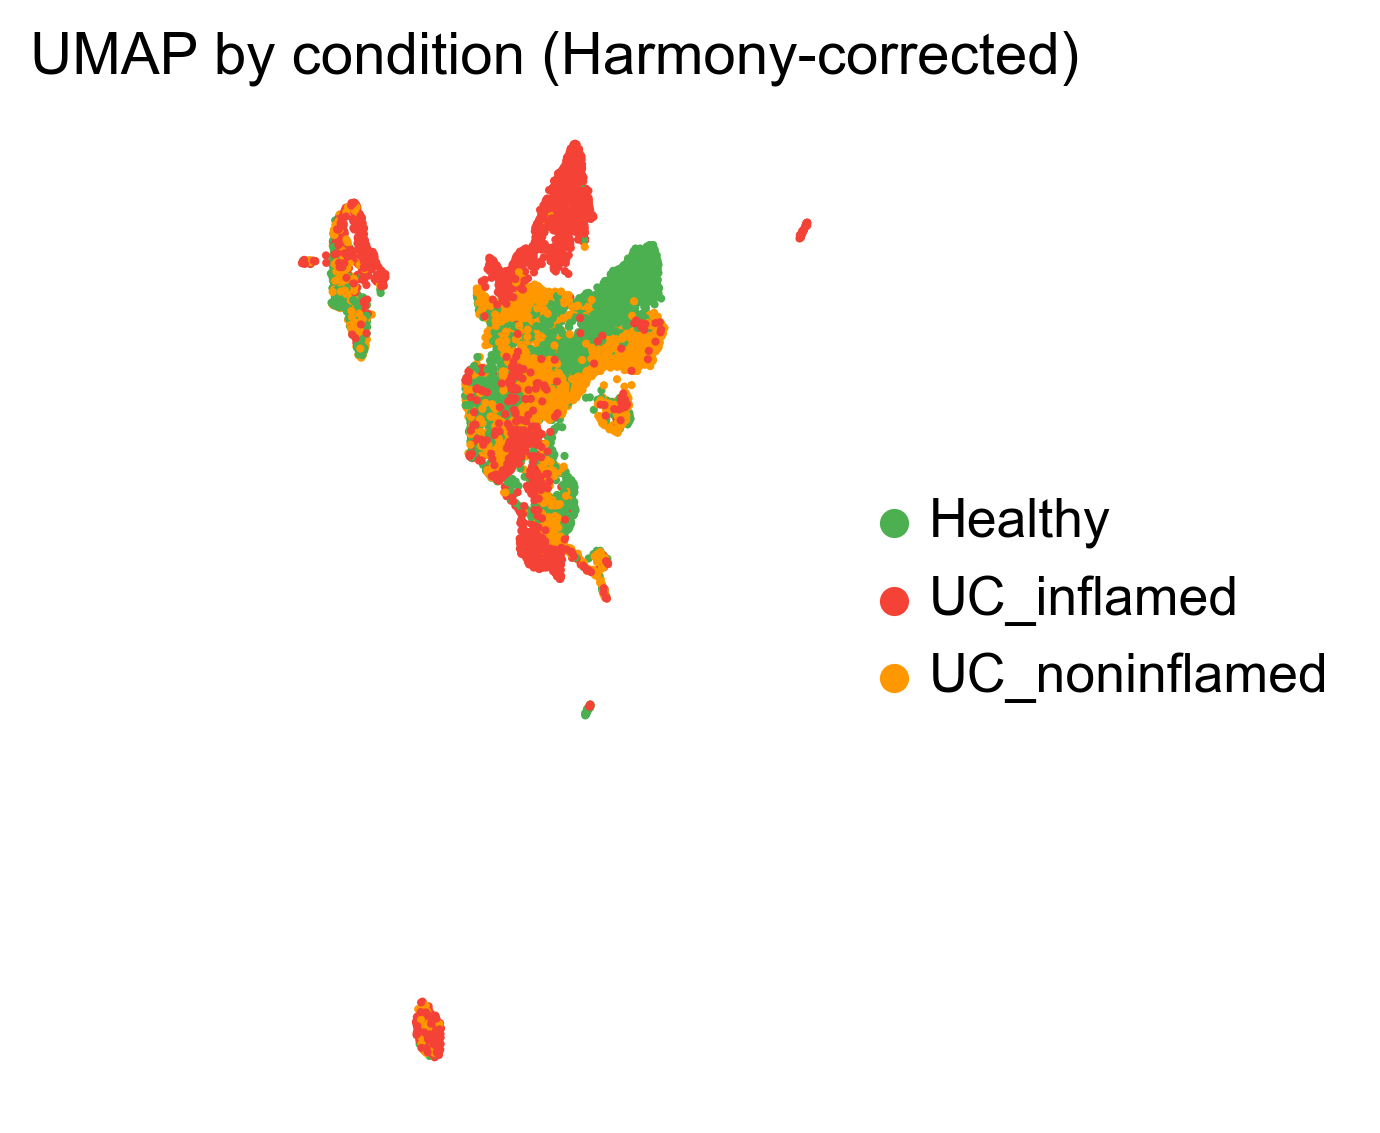

In [22]:
sc.pl.umap(
    adata, color='condition',
    palette=CONDITION_PALETTE,
    title='UMAP by condition (Harmony-corrected)',
    show=False
)
plt.tight_layout()
plt.savefig('figures/v2/04_umap_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


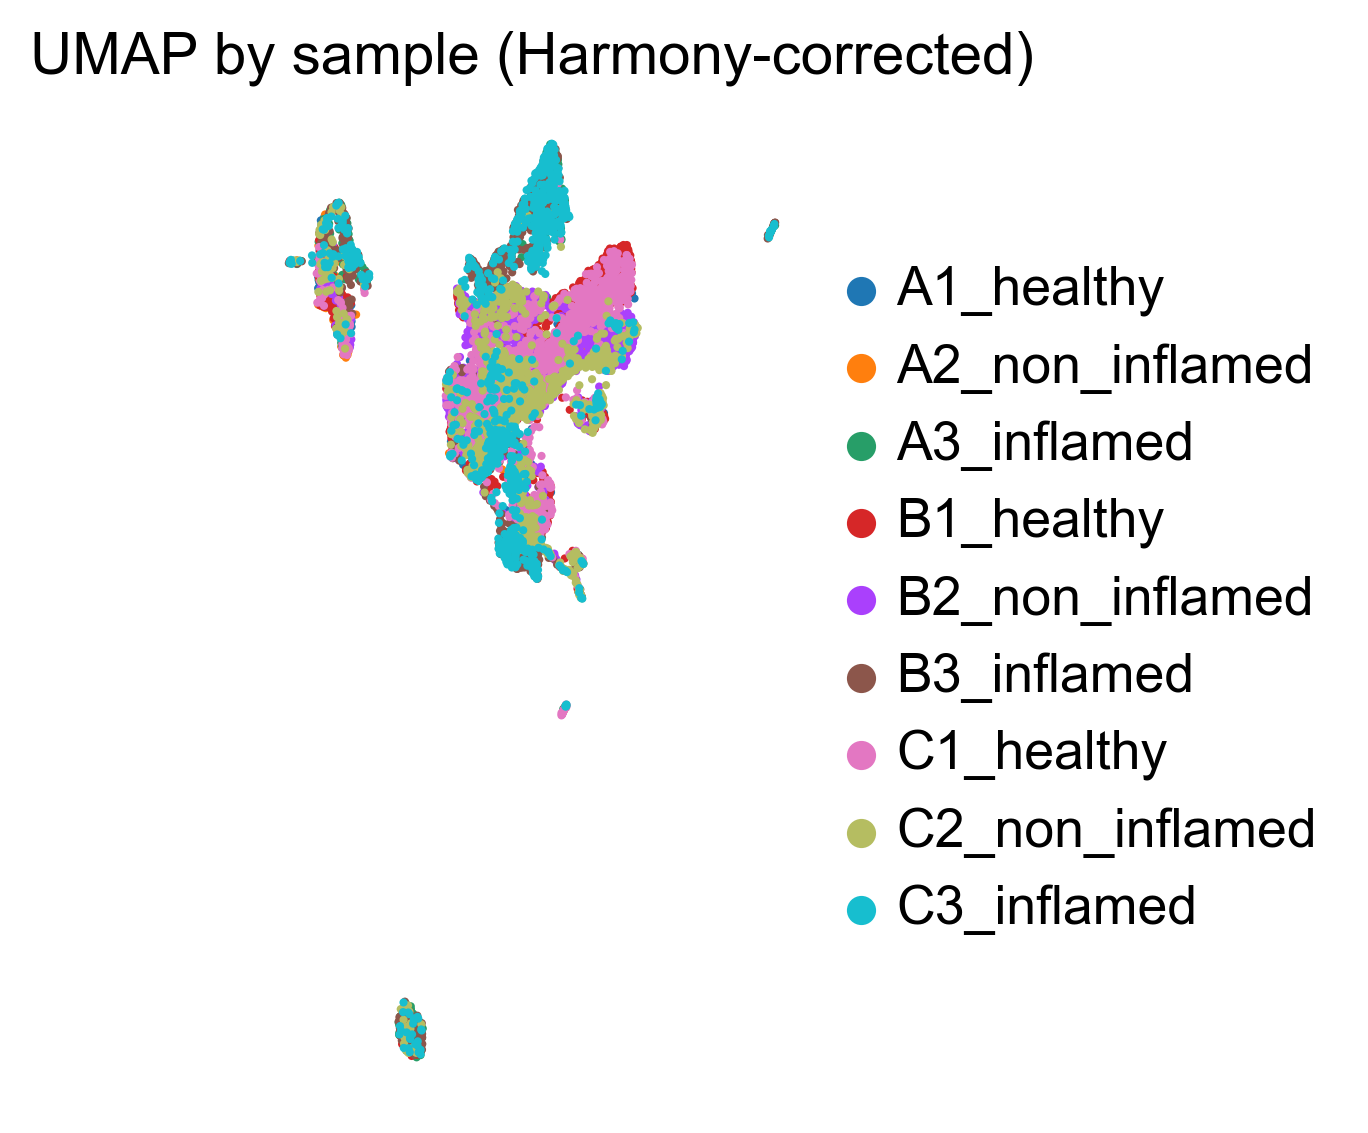

In [23]:
sc.pl.umap(
    adata, color='sample',
    title='UMAP by sample (Harmony-corrected)',
    show=False
)
plt.tight_layout()
plt.savefig('figures/v2/04_umap_by_sample.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Leiden clustering

Leiden is a community-detection algorithm applied to the k-NN graph.
The `resolution` parameter controls granularity — higher values produce more clusters.
We test four resolutions and select the one with the most biologically coherent clusters.

Resolution guide for this dataset:
- **0.5** → coarse; captures major lineages (absorptive, secretory, stem)
- **0.8** → intermediate; separates major subtypes
- **1.0** → fine; matches the resolution used in Parikh et al. (2019)
- **1.2** → very fine; may over-split; useful to check for rare populations

In [24]:
# Run Leiden at all four resolutions
resolutions = [0.5, 0.8, 1.0, 1.2]
for res in resolutions:
    sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}', random_state=RANDOM_STATE)
    n_clusters = adata.obs[f'leiden_{res}'].nunique()
    print(f"Resolution {res}: {n_clusters} clusters")

Resolution 0.5: 15 clusters
Resolution 0.8: 19 clusters
Resolution 1.0: 22 clusters
Resolution 1.2: 22 clusters


/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


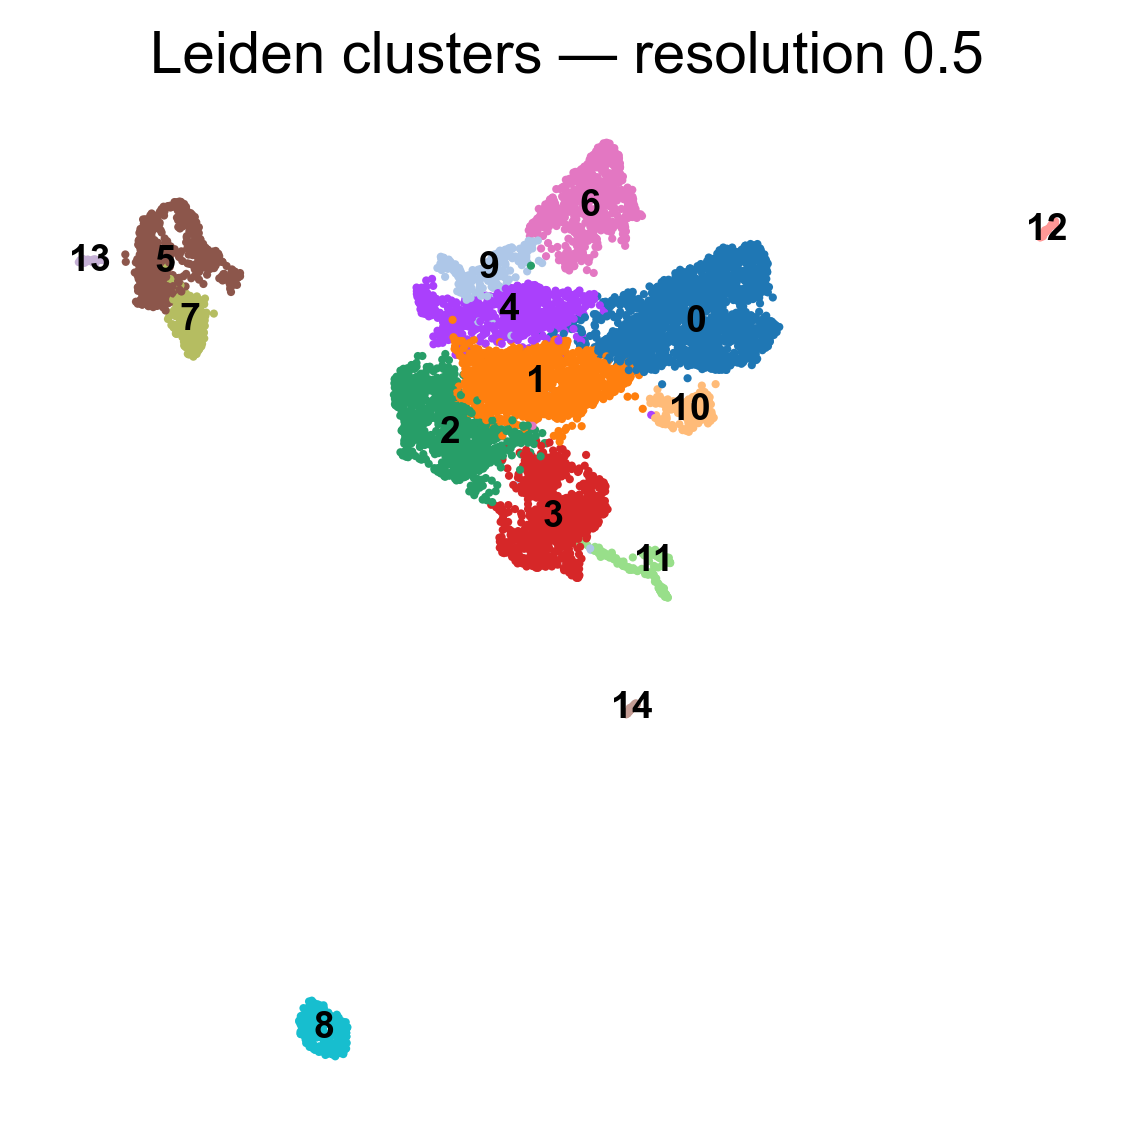

In [25]:
sc.pl.umap(
    adata, color='leiden_0.5',
    legend_loc='on data', legend_fontsize=9,
    title='Leiden clusters — resolution 0.5',
    show=False
)
plt.tight_layout()
plt.savefig('figures/v2/04_umap_leiden_0.5.png', dpi=150, bbox_inches='tight')
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


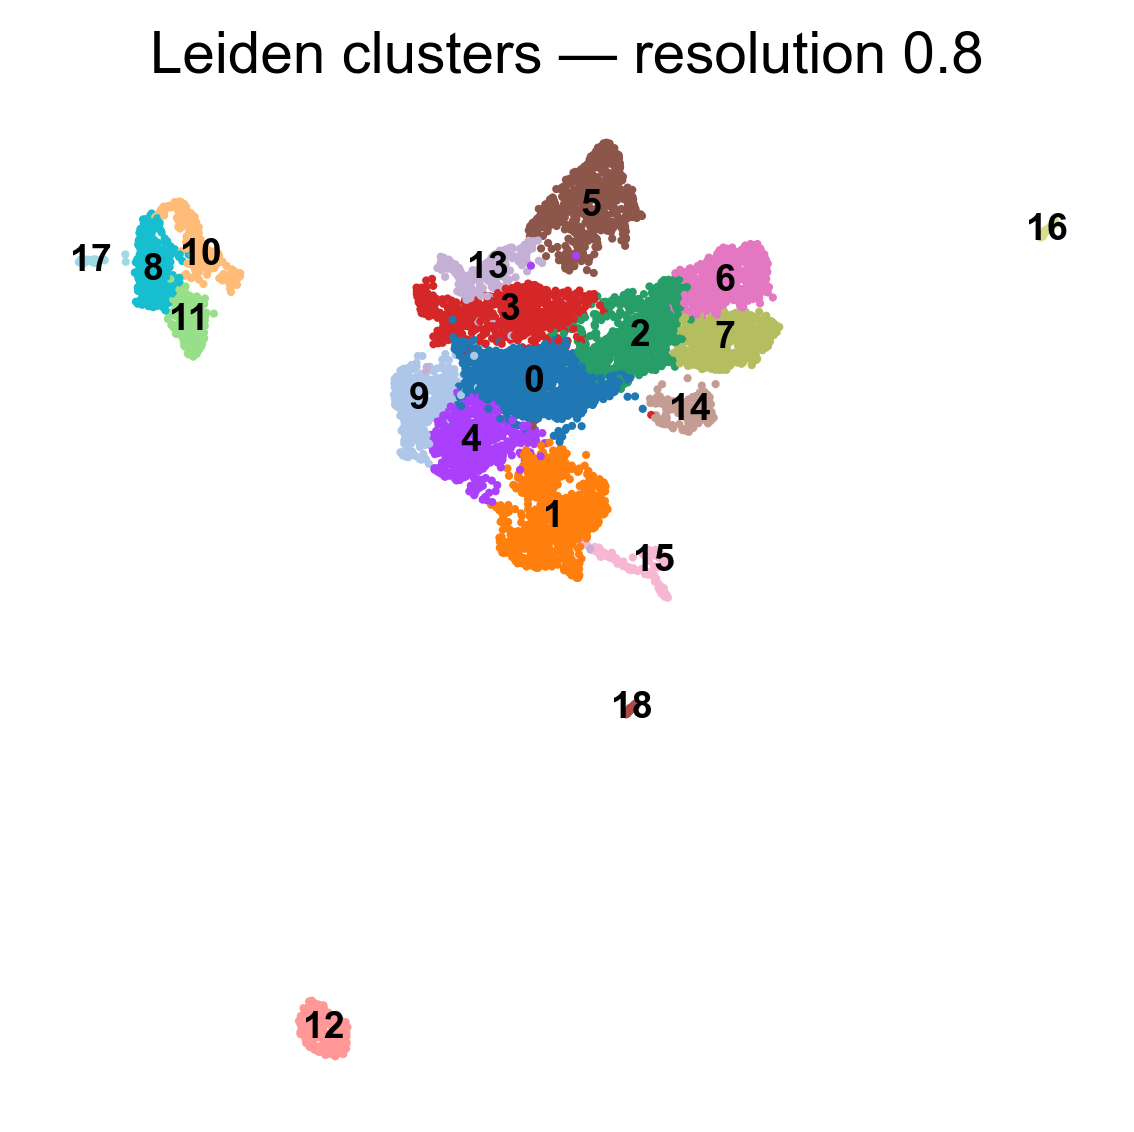

In [26]:
sc.pl.umap(
    adata, color='leiden_0.8',
    legend_loc='on data', legend_fontsize=9,
    title='Leiden clusters — resolution 0.8',
    show=False
)
plt.tight_layout()
plt.savefig('figures/v2/04_umap_leiden_0.8.png', dpi=150, bbox_inches='tight')
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


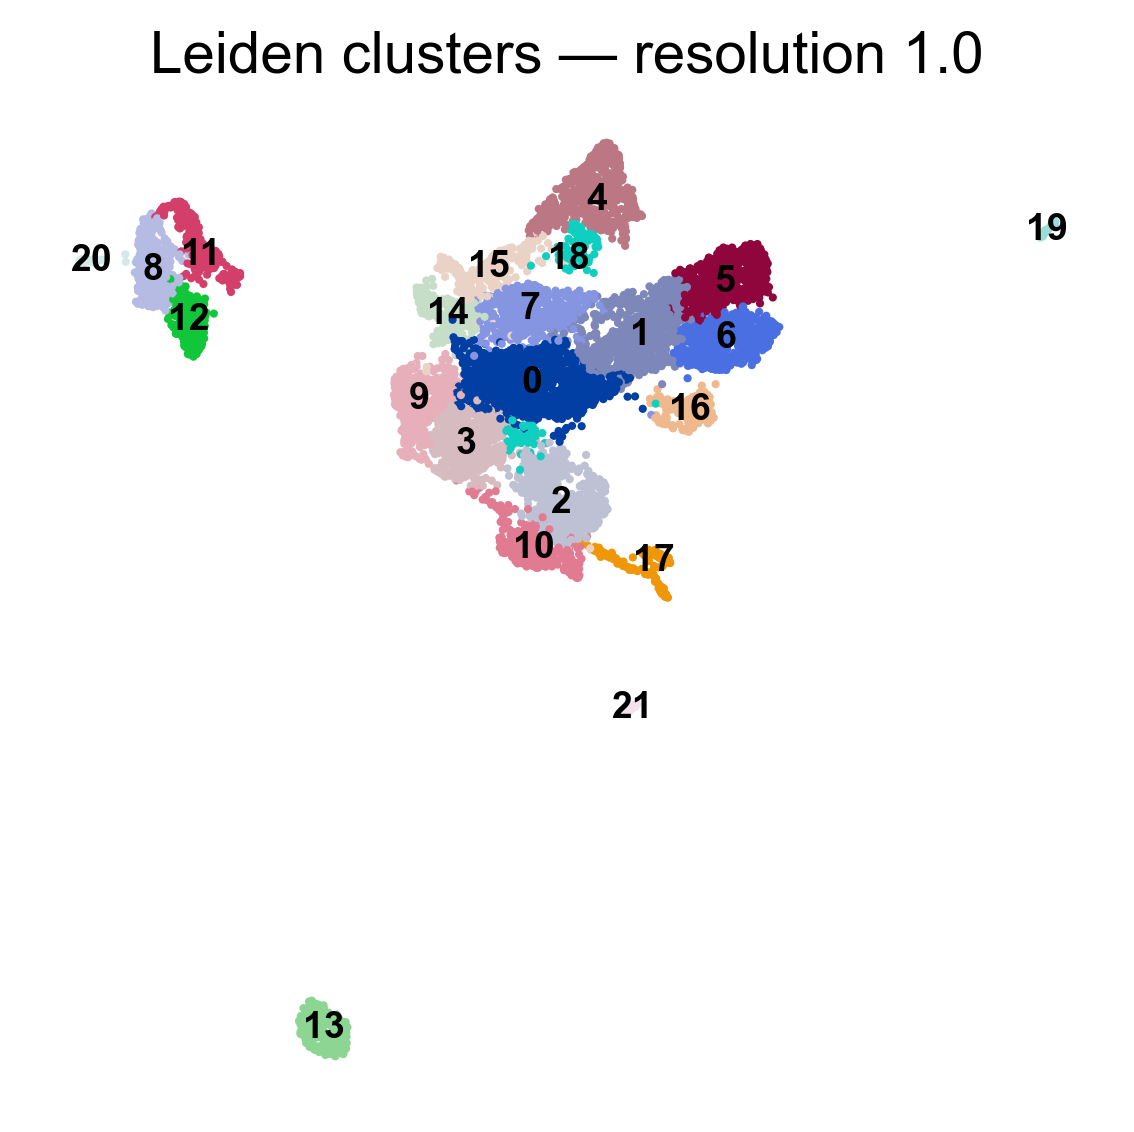

In [27]:
sc.pl.umap(
    adata, color='leiden_1.0',
    legend_loc='on data', legend_fontsize=9,
    title='Leiden clusters — resolution 1.0',
    show=False
)
plt.tight_layout()
plt.savefig('figures/v2/04_umap_leiden_1.0.png', dpi=150, bbox_inches='tight')
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/homebrew/Caskroom/miniconda/base/envs/scrna-uc/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


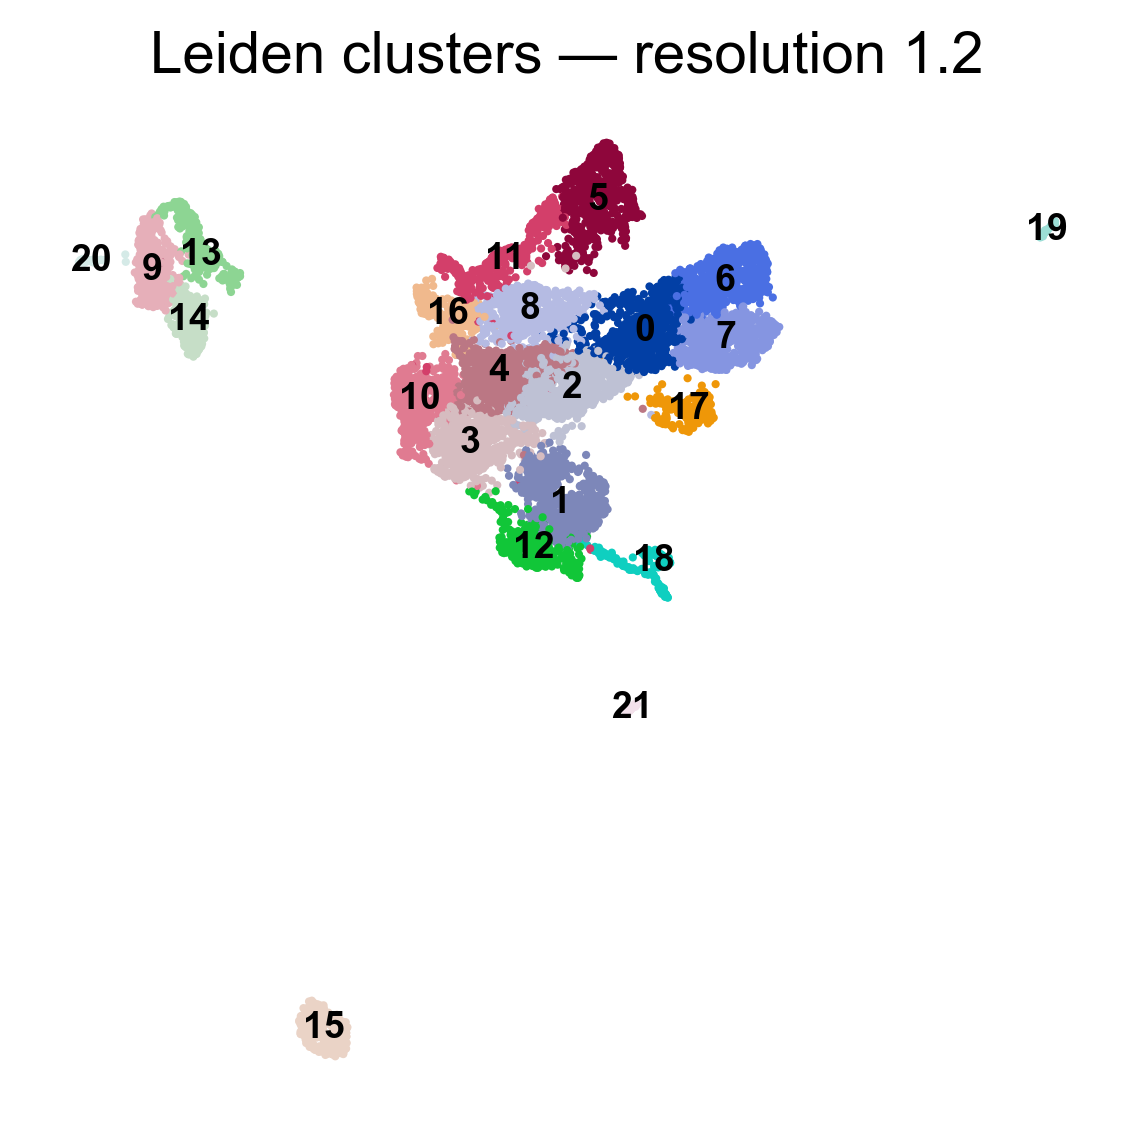

In [28]:
sc.pl.umap(
    adata, color='leiden_1.2',
    legend_loc='on data', legend_fontsize=9,
    title='Leiden clusters — resolution 1.2',
    show=False
)
plt.tight_layout()
plt.savefig('figures/v2/04_umap_leiden_1.2.png', dpi=150, bbox_inches='tight')
plt.show()

## Cluster composition by condition

For each cluster we calculate the fraction of cells from each condition.
This is a preliminary sanity check — condition-specific clusters suggest
disease-associated cell states, which we will interpret in notebook 05.

We use resolution 1.0 for annotation (matches Parikh et al. 2019 granularity).

/var/folders/mr/f3825hy10rjbrjd_85fs57bc0000gp/T/ipykernel_8435/1039326477.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby([LEIDEN_KEY, 'condition'])


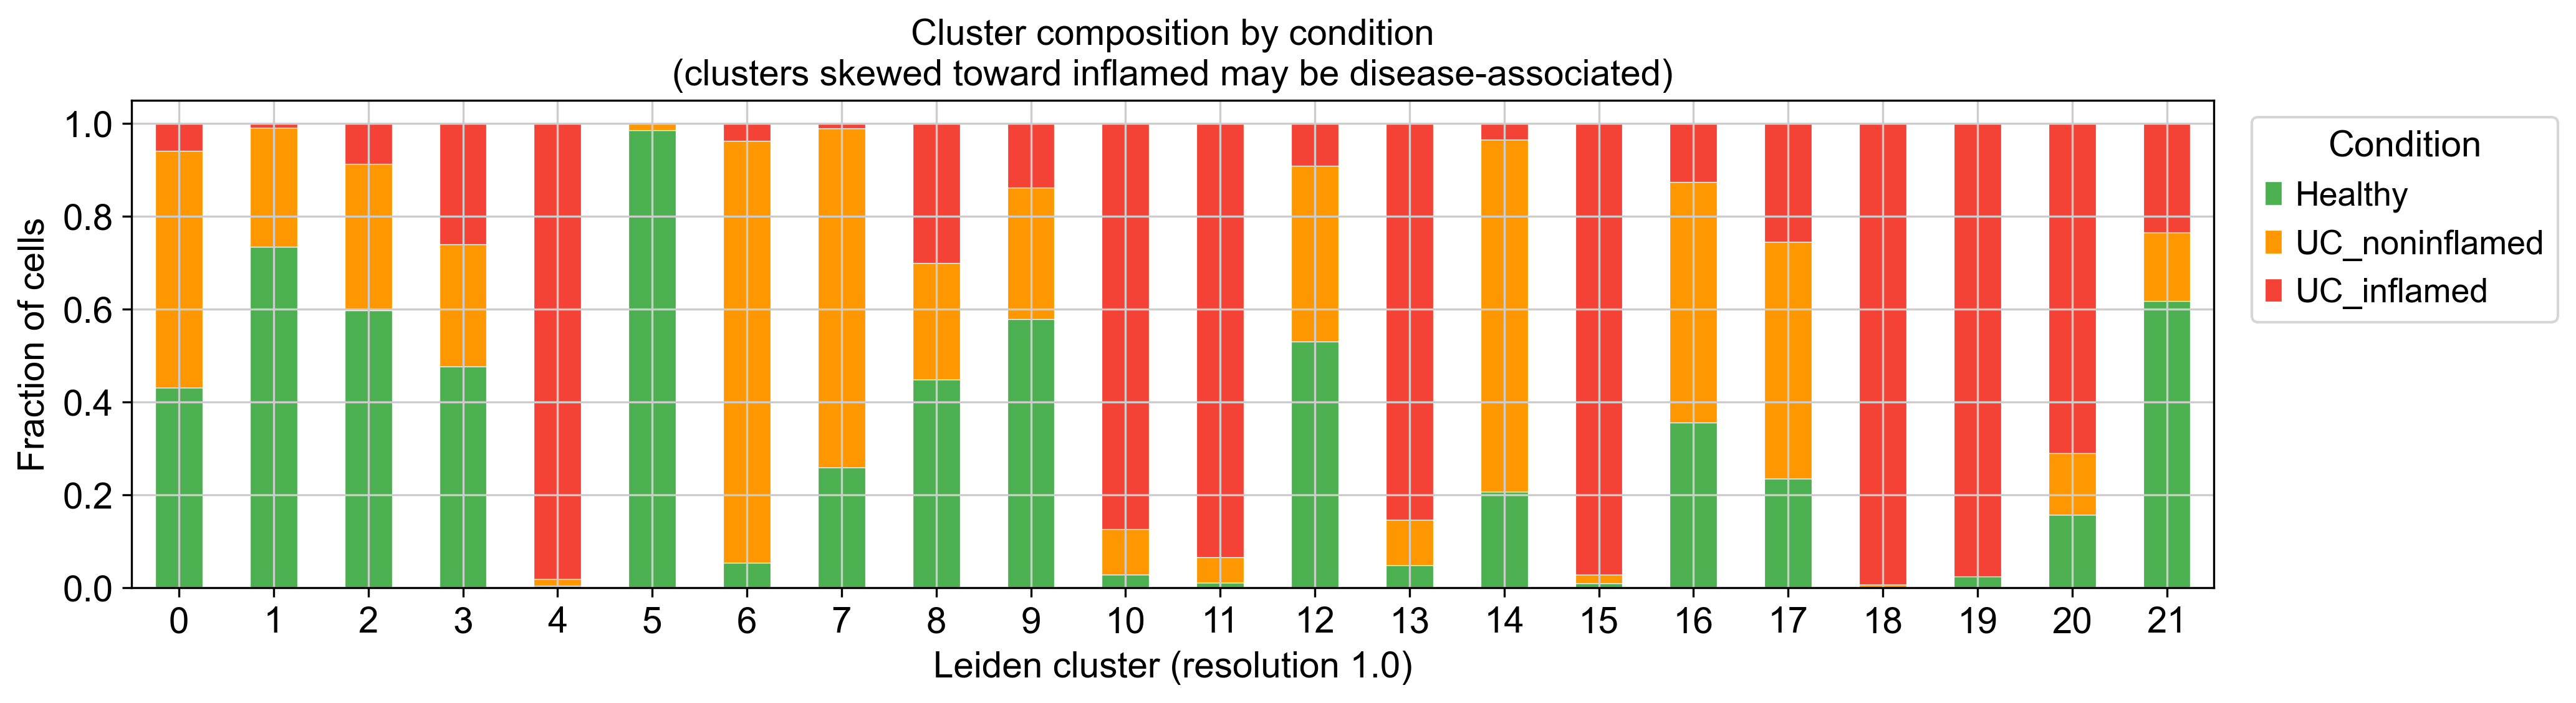

In [29]:
# Set the working resolution
LEIDEN_KEY = 'leiden_1.0'
adata.obs['leiden'] = adata.obs[LEIDEN_KEY].copy()

# Compute condition fraction per cluster
comp = (
    adata.obs.groupby([LEIDEN_KEY, 'condition'])
    .size()
    .unstack(fill_value=0)
)
# Normalise to row fractions
comp_frac = comp.div(comp.sum(axis=1), axis=0)
comp_frac = comp_frac[['Healthy', 'UC_noninflamed', 'UC_inflamed']]

fig, ax = plt.subplots(figsize=(14, 4))
comp_frac.plot(
    kind='bar', stacked=True,
    color=[CONDITION_PALETTE[c] for c in comp_frac.columns],
    ax=ax, edgecolor='white', linewidth=0.3
)
ax.set_xlabel('Leiden cluster (resolution 1.0)')
ax.set_ylabel('Fraction of cells')
ax.set_title('Cluster composition by condition\n(clusters skewed toward inflamed may be disease-associated)')
ax.legend(title='Condition', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('figures/v2/04_cluster_composition_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Print cluster sizes
cluster_sizes = adata.obs[LEIDEN_KEY].value_counts().sort_index()
print("Cluster sizes (leiden 1.0):")
print(cluster_sizes.to_string())
print(f"\nTotal clusters: {len(cluster_sizes)}")

Cluster sizes (leiden 1.0):
leiden_1.0
0     1047
1      799
2      624
3      529
4      515
5      492
6      478
7      478
8      386
9      375
10     286
11     260
12     251
13     246
14     232
15     213
16     174
17     153
18     141
19      40
20      38
21      34

Total clusters: 22


## Save clustered AnnData

In [31]:
out_path = 'data/processed/v2/GSE116222_v2_clustered.h5ad'
adata.write_h5ad(out_path)
print(f"Saved : {out_path}")
print(f"Size  : {os.path.getsize(out_path) / 1e6:.1f} MB")
print(f"Shape : {adata.n_obs:,} cells × {adata.n_vars:,} genes")
print(f"\n{adata}")

Saved : data/processed/v2/GSE116222_v2_clustered.h5ad
Size  : 237.6 MB
Shape : 7,791 cells × 3,000 genes

AnnData object with n_obs × n_vars = 7791 × 3000
    obs: 'sample', 'condition', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'log1p_total_counts_ribo', 'leiden_0.5', 'leiden_0.8', 'leiden_1.0', 'leiden_1.2', 'leiden'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_mean_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'condition_colors', 'hvg', 'log1p', 'sample_colors', 'pca', 'batch_colors', 'neighbors', 'umap', 'leiden', 'leiden_0.5_colors', 'leiden_0.8_colors', 'leiden_1.0_colors', 'leiden_1.2_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'c